In [56]:
import mofr

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagRegression_strategy.backtest_class import BacktestLL
from Strategies.LeadLagRegression_strategy.strategy_class import StrategyLL, VolumeClass
from support_functions import calculate_MACD, calculate_regression_model_price, calc_vol_intensity_index
tol=(1e-1)/2

import seaborn as sns

from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Legend
from bokeh.io import output_notebook
from scipy.stats import gaussian_kde

In [58]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_tree
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [59]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
import warnings
warnings.filterwarnings('ignore')

In [61]:
burnout_period=10
stop_profit=0.5
makeagg_ratio=0.6
trail_stop=0

take_profit=0.3
stop_loss=-0.3

br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

In [62]:
##########################
param_dict = {}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.1

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop


param_dict['br_fee'] = br_fee
##########################


strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.param_dict=param_dict

# Data preparation

In [63]:
data_lead =pd.concat([pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_jan_feb.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_mar_apr.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_may_june.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_july.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_aug.csv',
                    parse_dates=['datetime']).reset_index()])


data_lag =pd.concat([pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_jan_feb.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_mar_apr.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_may_june.csv',
                    parse_dates=['datetime']).reset_index(), pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_july_aug.csv',
                    parse_dates=['datetime']).reset_index()])


KeyboardInterrupt



In [ ]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [ ]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [ ]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [ ]:
data_lag['date']=data_lag['datetime'].apply(lambda x: x.date())

## Predictor calculation

In [ ]:
data_lag['timestamp']=data_lag['datetime']
data_lead['timestamp']=data_lead['datetime']

data_lag=calculate_MACD(data_lag, 6,14)
data_lag=calculate_MACD(data_lag, 12,26)
data_lag=calculate_MACD(data_lag, 18,38)

data_lead=calculate_regression_model_price(data_lead, data_lag, 10, 10, 3)

        
data_lag['tag']='lag'
data_lead['tag']='lead'

data_lag= pd.concat([data_lag, data_lead[['datetime', 'timestamp', 'tag', 'trd_price', 'lag_price_predicted', 'lag_price_predicted_datetime', 'lag_price_tick', 'coef1', 'coef2', 'lead_price_tick']].reset_index(drop=True)]).reset_index(
    drop=True).sort_values('datetime').reset_index()

del data_lag['level_0'], data_lag['index']

# Convert the timestamp to date and set it as a separate column if not already done
data_lag['date'] = data_lag['datetime'].dt.date


data_lag=calc_vol_intensity_index(data_lag, 3, 'lead')
data_lag=calc_vol_intensity_index(data_lag, 5, 'lead')
data_lag=calc_vol_intensity_index(data_lag, 10, 'lead')
data_lag=calc_vol_intensity_index(data_lag, 3, 'lag')
data_lag=calc_vol_intensity_index(data_lag, 5, 'lag')
data_lag=calc_vol_intensity_index(data_lag, 10, 'lag')



# Forward fill within each day
data_lag['bid_price'] = data_lag.groupby('date')['bid_price'].ffill()
data_lag['ask_price'] = data_lag.groupby('date')['ask_price'].ffill()
data_lag['mid_price'] = data_lag.groupby('date')['mid_price'].ffill()
data_lag['MACD_6_14'] = data_lag.groupby('date')['MACD_6_14'].ffill()
data_lag['MACD_12_26'] = data_lag.groupby('date')['MACD_12_26'].ffill()
data_lag['MACD_18_38'] = data_lag.groupby('date')['MACD_18_38'].ffill()


data_lag=data_lag.dropna(subset=['bid_price', 'ask_price', 'mid_price'])

In [ ]:
data_lag.head()

## Target Calculation

In [ ]:
def calculate_close_slot_long(open_price, open_time, row):
    
        if (row['ask_price']-row['bid_price']>param_dict['ba_max']) or row['tag']!='lag':
            return (0,0)
    
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        strategy_class.tag=row['tag']
        
        #strategy_class.MACD = row['MACD']
        #strategy_class.lag_price_predicted_datetime = row['lag_price_predicted_datetime']
        #strategy_class.lag_price_tick = row['lag_price_tick']
        #strategy_class.lead_price_tick = row['lead_price_tick']
        
        #strategy_class.coef1 = row['coef1']
        #strategy_class.coef2 = row['coef2']

        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=1
        
        return strategy_class.calculate_close_slot()
    
def calculate_close_slot_short(open_price, open_time, row):

        if row['ask_price']-row['bid_price']>param_dict['ba_max'] or row['tag']!='lag':
            return (0,0)
        
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        strategy_class.tag=row['tag']
        
        
#         strategy_class.MACD = row['MACD']
#         strategy_class.lag_price_predicted_datetime = row['lag_price_predicted_datetime']
#         strategy_class.lag_price_tick = row['lag_price_tick']
#         strategy_class.lead_price_tick = row['lead_price_tick']
        
#         strategy_class.coef1 = row['coef1']
#         strategy_class.coef2 = row['coef2']
        
        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=-1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=-1
        
        return strategy_class.calculate_close_slot()

    
def calculate_profit_long(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['ask_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_long(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return price-open_price-2*param_dict['br_fee']
    
    return 0

def calculate_profit_short(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['bid_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_short(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return open_price-price-2*param_dict['br_fee']
    
    return 0

In [ ]:
df_filtered=data_lag[data_lag['tag']=='lead']

In [ ]:
for date in sorted(list(set(df_filtered.date))):
    print(date)
    a=data_lag[data_lag['date']==date]
    df_filtered.loc[df_filtered['date']==date, 'profit_long']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_long(row, a), axis=1)
    df_filtered.loc[df_filtered['date']==date, 'profit_short']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_short(row, a), axis=1)

In [ ]:
df_filtered=df_filtered[df_filtered['datetime'].apply(lambda x: x.hour>8 and  x.hour<17)]

In [ ]:
df_filtered.to_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_jan_aug_enriched_burnout10_tp03_sl03_bamax01.csv')

In [ ]:
df_filtered=pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_jan_aug_enriched_burnout10_tp03_sl03_bamax01.csv')
del df_filtered['Unnamed: 0']

In [64]:
#%store -r df_filtered

In [65]:
df_filtered.head()

,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff,date,timestamp,...,profit_long,profit_short,VII_3_ratio,VII_5_ratio,VII_10_ratio,predicted_return,ba_spread,month,week,price_diff
0,2024-01-02 09:00:40.962116718,92.00,NaN,78.10,79.0,78.550,NaN,NaN,2024-01-02,2024-01-02 09:00:40.962116718,...,NaN,NaN,NaN,NaN,NaN,NaN,0.90,1,1,NaN
1,2024-01-02 09:00:41.104269743,91.97,NaN,78.11,79.0,78.555,NaN,NaN,2024-01-02,2024-01-02 09:00:41.104269743,...,NaN,NaN,NaN,NaN,NaN,NaN,0.89,1,1,NaN
2,2024-01-02 09:00:41.159442425,92.00,NaN,78.11,79.0,78.555,NaN,NaN,2024-01-02,2024-01-02 09:00:41.159442425,...,NaN,NaN,NaN,NaN,NaN,NaN,0.89,1,1,NaN
3,2024-01-02 09:00:50.746176004,91.96,NaN,78.14,79.0,78.570,NaN,NaN,2024-01-02,2024-01-02 09:00:50.746176004,...,NaN,NaN,NaN,NaN,NaN,NaN,0.86,1,1,NaN
4,2024-01-02 09:02:07.654365540,92.34,NaN,78.14,79.0,78.570,NaN,NaN,2024-01-02,2024-01-02 09:02:07.654365540,...,NaN,NaN,NaN,NaN,NaN,NaN,0.86,1,1,NaN


# Model Calculation

In [66]:
seed=2
ba_max=0.1

In [67]:
df_filtered['VII_3_ratio']=(df_filtered['VII_lead_3']/df_filtered['VII_lag_3'].replace(0, 0.00001)).apply(float)
df_filtered['VII_5_ratio']=(df_filtered['VII_lead_5']/df_filtered['VII_lag_5'].replace(0, 0.00001)).apply(float)
df_filtered['VII_10_ratio']=(df_filtered['VII_lead_10']/df_filtered['VII_lag_10'].replace(0, 0.00001)).apply(float)

df_filtered['predicted_return']=df_filtered['lag_price_predicted']/df_filtered['lag_price_tick']

In [68]:
df_filtered['ba_spread']=df_filtered['ask_price']-df_filtered['bid_price']

In [69]:
df_filtered['date'] = pd.to_datetime(df_filtered['date'], errors='coerce')
df_filtered['month']= df_filtered['date'].dt.month
df_filtered['week']= df_filtered['date'].dt.isocalendar().week

In [70]:
feature_cols=[
     'MACD_6_14',
     'MACD_12_26', 
     'MACD_18_38', 
     #'VII_lead_3', 
     #'VII_lead_5', 
     #'VII_lead_10',
     #'VII_lag_3', 
     #'VII_lag_5', 
     #'VII_lag_10',
     #'VII_3_ratio',
     #'VII_5_ratio',
     #'VII_10_ratio',

     'price_diff',
     'predicted_return',
     'ba_spread'
]

## Long models

In [71]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['ask_price']

In [72]:
df_modelling=df_filtered.replace([np.inf, -np.inf], None).dropna(subset=feature_cols+['profit_long', 'profit_short']).reset_index(drop=True)

In [73]:
df_modelling['one']=1

In [74]:
#df_modelling=df_modelling[(df_modelling['MACD_12_26']>-0.05)&(df_modelling['price_diff']>-0.05)]
df_modelling=df_modelling[(df_modelling['ba_spread']<ba_max)]
#df_modelling=df_modelling[(df_modelling['month']<8)]

### XGBoost

In [75]:
df_modelling['y']=(df_modelling['profit_long']>0).apply(int)
df_modelling['y'].value_counts()

y
0    26894
1    16443
Name: count, dtype: int64

In [76]:
df_modelling['y'].value_counts(normalize=True)

y
0    0.620578
1    0.379422
Name: proportion, dtype: float64

In [77]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD_6_14,0.141340
1,MACD_12_26,0.148046
2,MACD_18_38,0.144504
3,price_diff,0.090793
4,predicted_return,0.139955
5,ba_spread,-0.048706


In [78]:
# Create a new column to store the XGB_SCORE
df_modelling['XGB_SCORE_LONG'] = None

# Sort the data by date
df_modelling = df_modelling.sort_values('date')

# Generate weekly ranges: We're going to use sliding windows with 2 weeks for training and 1 week for scoring
weeks = pd.date_range(df_modelling['date'].min(), df_modelling['date'].max(), freq='W')

for i in range(len(weeks) - 6):  # We subtract 5 to ensure we have enough weeks for a 4-week train and 1-week test
    train_start = weeks[i+2]
    train_end = weeks[i+2 + 3]  # End of the 4-week training period
    test_start = weeks[i]
    test_end = weeks[i + 2] # End of the 1-week test period\
    
    valid_start = weeks[i+2 + 3]
    valid_end = weeks[i+2 + 4] # End of the 1-week test period\
    
    #print(f'{test_start} and {test_end}')
    
    # Training data: last 2 weeks
    train_data = df_modelling[(df_modelling['date'] >= train_start) & (df_modelling['date'] < train_end)]
    
    # Testing data: next 1 week
    test_data = df_modelling[(df_modelling['date'] >= test_start) & (df_modelling['date'] < test_end)]
    
    # Testing data: next 1 week
    valid_data = df_modelling[(df_modelling['date'] >= valid_start) & (df_modelling['date'] < valid_end)]
    
    # Skip if there isn't enough data for the period
    if train_data.empty or test_data.empty:
        continue

 # Split into features and target
    X_train, y_train = train_data[feature_cols].apply(pd.to_numeric, errors='coerce'), train_data['y']
    X_test, y_test = test_data[feature_cols].apply(pd.to_numeric, errors='coerce'), test_data['y']
    X_valid, y_valid = valid_data[feature_cols].apply(pd.to_numeric, errors='coerce'), valid_data['y']


    # Create DMatrix for XGBoost (required for early stopping)
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)


    # Set up the parameters for XGBoost
    params = {
    'objective': 'binary:logistic',  # For binary classification
    'eval_metric': 'logloss',  # Use log-loss to evaluate performance
    'max_depth': 2,  # Prevent overfitting by limiting tree depth
    'eta': 0.1,  # Learning rate, lower to prevent overfitting
    'gamma': 1,  # Regularization to reduce overfitting
    'lambda': 1,  # L2 regularization term
    'alpha': 0.1  # L1 regularization term
    }

    # Set up evaluation list
    evals = [(dtrain, 'train'), (dtest, 'test')]

    # Train the model with early stopping
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=100,  # Maximum number of boosting rounds
        evals=evals,
        early_stopping_rounds=10,  # Stop if test error doesn't improve after 10 rounds
        verbose_eval=True  # Show progress
    )

    # Predict for the training and testing periods
    predictions_train = model.predict(dtrain)
    predictions = model.predict(dvalid)
    
    lr_model = LogisticRegression()
    lr_model.fit(X_train, y_train)
    
    predictions_lr=lr_model.predict_proba(X_valid)[:, 1]

    # Insert predictions into the original DataFrame
    df_modelling.loc[train_data.index, 'XGB_SCORE_LONG_TRAIN'] = predictions_train
    df_modelling.loc[valid_data.index, 'XGB_SCORE_LONG'] = predictions
    df_modelling.loc[valid_data.index, 'LR_SCORE_LONG'] = predictions_lr

[0]	train-logloss:0.63647	test-logloss:0.65027
[1]	train-logloss:0.63126	test-logloss:0.65039
[2]	train-logloss:0.62657	test-logloss:0.65090
[3]	train-logloss:0.62119	test-logloss:0.65079
[4]	train-logloss:0.61713	test-logloss:0.64975
[5]	train-logloss:0.61315	test-logloss:0.65042
[6]	train-logloss:0.60971	test-logloss:0.65130
[7]	train-logloss:0.60607	test-logloss:0.65213
[8]	train-logloss:0.60266	test-logloss:0.65388
[9]	train-logloss:0.60026	test-logloss:0.65261
[10]	train-logloss:0.59711	test-logloss:0.65216
[11]	train-logloss:0.59433	test-logloss:0.65304
[12]	train-logloss:0.59236	test-logloss:0.65202
[13]	train-logloss:0.59054	test-logloss:0.65149
[0]	train-logloss:0.57310	test-logloss:0.64609
[1]	train-logloss:0.56824	test-logloss:0.64751
[2]	train-logloss:0.56431	test-logloss:0.64858
[3]	train-logloss:0.55996	test-logloss:0.64957
[4]	train-logloss:0.55473	test-logloss:0.65005
[5]	train-logloss:0.55117	test-logloss:0.65088
[6]	train-logloss:0.54812	test-logloss:0.65153
[7]	train

[6]	train-logloss:0.64080	test-logloss:0.66143
[7]	train-logloss:0.63801	test-logloss:0.66008
[8]	train-logloss:0.63514	test-logloss:0.66137
[9]	train-logloss:0.63344	test-logloss:0.66164
[10]	train-logloss:0.63140	test-logloss:0.66085
[11]	train-logloss:0.62982	test-logloss:0.66091
[12]	train-logloss:0.62846	test-logloss:0.66149
[13]	train-logloss:0.62697	test-logloss:0.66191
[14]	train-logloss:0.62496	test-logloss:0.66279
[15]	train-logloss:0.62410	test-logloss:0.66301
[16]	train-logloss:0.62253	test-logloss:0.66350
[0]	train-logloss:0.65237	test-logloss:0.66396
[1]	train-logloss:0.64625	test-logloss:0.66268
[2]	train-logloss:0.64126	test-logloss:0.66200
[3]	train-logloss:0.63696	test-logloss:0.66124
[4]	train-logloss:0.63342	test-logloss:0.66090
[5]	train-logloss:0.63027	test-logloss:0.66185
[6]	train-logloss:0.62770	test-logloss:0.66235
[7]	train-logloss:0.62507	test-logloss:0.66182
[8]	train-logloss:0.62161	test-logloss:0.66172
[9]	train-logloss:0.61951	test-logloss:0.66177
[10]	t

[2]	train-logloss:0.66775	test-logloss:0.64941
[3]	train-logloss:0.66332	test-logloss:0.64970
[4]	train-logloss:0.65911	test-logloss:0.64973
[5]	train-logloss:0.65552	test-logloss:0.65080
[6]	train-logloss:0.65259	test-logloss:0.65190
[7]	train-logloss:0.64986	test-logloss:0.65247
[8]	train-logloss:0.64756	test-logloss:0.65290
[9]	train-logloss:0.64548	test-logloss:0.65398
[10]	train-logloss:0.64291	test-logloss:0.65461
[11]	train-logloss:0.64096	test-logloss:0.65569
[12]	train-logloss:0.63933	test-logloss:0.65668
[0]	train-logloss:0.65974	test-logloss:0.67789
[1]	train-logloss:0.65172	test-logloss:0.67728
[2]	train-logloss:0.64488	test-logloss:0.67786
[3]	train-logloss:0.63919	test-logloss:0.67766
[4]	train-logloss:0.63404	test-logloss:0.67818
[5]	train-logloss:0.62901	test-logloss:0.68029
[6]	train-logloss:0.62494	test-logloss:0.68176
[7]	train-logloss:0.62080	test-logloss:0.68247
[8]	train-logloss:0.61730	test-logloss:0.68448
[9]	train-logloss:0.61417	test-logloss:0.68652
[10]	train

[1]	train-logloss:0.67922	test-logloss:0.64458
[2]	train-logloss:0.67505	test-logloss:0.64336
[3]	train-logloss:0.67186	test-logloss:0.64242
[4]	train-logloss:0.66908	test-logloss:0.64124
[5]	train-logloss:0.66626	test-logloss:0.63893
[6]	train-logloss:0.66417	test-logloss:0.63717
[7]	train-logloss:0.66172	test-logloss:0.63638
[8]	train-logloss:0.66008	test-logloss:0.63507
[9]	train-logloss:0.65798	test-logloss:0.63353
[10]	train-logloss:0.65672	test-logloss:0.63379
[11]	train-logloss:0.65546	test-logloss:0.63273
[12]	train-logloss:0.65376	test-logloss:0.63186
[13]	train-logloss:0.65184	test-logloss:0.63201
[14]	train-logloss:0.65020	test-logloss:0.63259
[15]	train-logloss:0.64832	test-logloss:0.63216
[16]	train-logloss:0.64746	test-logloss:0.63231
[17]	train-logloss:0.64592	test-logloss:0.63262
[18]	train-logloss:0.64446	test-logloss:0.63327
[19]	train-logloss:0.64296	test-logloss:0.63355
[20]	train-logloss:0.64148	test-logloss:0.63418
[21]	train-logloss:0.64027	test-logloss:0.63462
[

In [79]:
print('The Lift on the train set is: '+ str(mofr.metrics.lift(df_modelling[df_modelling['XGB_SCORE_LONG_TRAIN'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_LONG_TRAIN'].isnull()==False]['XGB_SCORE_LONG_TRAIN'])))
print('The gini on the train set is: '+ str(mofr.metrics.gini(df_modelling[df_modelling['XGB_SCORE_LONG_TRAIN'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_LONG_TRAIN'].isnull()==False]['XGB_SCORE_LONG_TRAIN'])))
# print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['XGB_SCORE_LONG'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['XGB_SCORE_LONG'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['XGB_SCORE_LONG'])))
# print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False]['XGB_SCORE_LONG'].apply(lambda x: int(x>0.5)))))
print('\n')
# Sort the DataFrame by the XGB_SCORE_LONG column in descending order
df_modelling['CURRENT_LOGIC']=((df_modelling['MACD_12_26']>0.05)&(df_modelling['price_diff']>0.1)&(df_modelling['XGB_SCORE_LONG'].isnull()==False)).apply(int)
df_modelling['SIMPLE_SCORE']=0.33*df_modelling['MACD_12_26']+df_modelling['price_diff']
n=sum(df_modelling['CURRENT_LOGIC'])
df_top100 = df_modelling.sort_values(by='XGB_SCORE_LONG', ascending=False).head(n)
df_top100_train = df_modelling.sort_values(by='XGB_SCORE_LONG_TRAIN', ascending=False).head(n)
df_top100_simple = df_modelling.sort_values(by='SIMPLE_SCORE', ascending=False).head(n)
df_top100_lr = df_modelling.sort_values(by='LR_SCORE_LONG', ascending=False).head(n)



# Calculate precision based on the top 100 observations
precision_test = df_top100['y'].sum()/n
precision_train = df_top100_train['y'].sum()/n
precision_simple = df_top100_simple['y'].sum()/n
precision=df_modelling[df_modelling['CURRENT_LOGIC']==1]['y'].mean()
precision_lr = df_top100_lr['y'].sum()/n



# Create a DataFrame with the precision data
precision_data = {
    'Set': ['Train', 'Test', 'LR', 'Simple', 'Current Model'],
    'Top N Observations': [n, n, n, n, n],
    'Precision': [precision_train, precision_test, precision_lr, precision_simple,precision],
    'Unique Days': [
        len(df_top100_train['date'].unique()), 
        len(df_top100['date'].unique()), 
        len(df_top100_lr['date'].unique()), 

        len(df_top100_simple['date'].unique()), 
        len(df_modelling[df_modelling['CURRENT_LOGIC']==1]['date'].unique())
    ]
}

# Create DataFrame to store the results
df_precision = pd.DataFrame(precision_data)
df_precision

The Lift on the train set is: 1.9789422121180218
The gini on the train set is: 0.44367484563462956


The Lift on the test set is: 1.153959975835621
The gini on the test set is: 0.07165629600842349




,Set,Top N Observations,Precision,Unique Days
0,Train,963,0.902388,55
1,Test,963,0.408100,74
2,LR,963,0.494289,64
3,Simple,963,0.473520,110
4,Current Model,963,0.570093,99


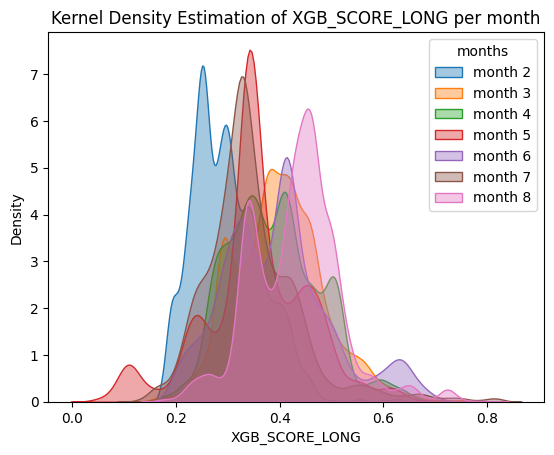

In [80]:
for month, group in df_modelling[df_modelling['XGB_SCORE_LONG'].isnull()==False].groupby('month'):
    sns.kdeplot(group['XGB_SCORE_LONG'], label=f'month {month}', fill=True, alpha=0.4)

# Add labels and legend
plt.xlabel('XGB_SCORE_LONG')
plt.ylabel('Density')
plt.title('Kernel Density Estimation of XGB_SCORE_LONG per month')
plt.legend(title='months')

# Show the plot
plt.show()

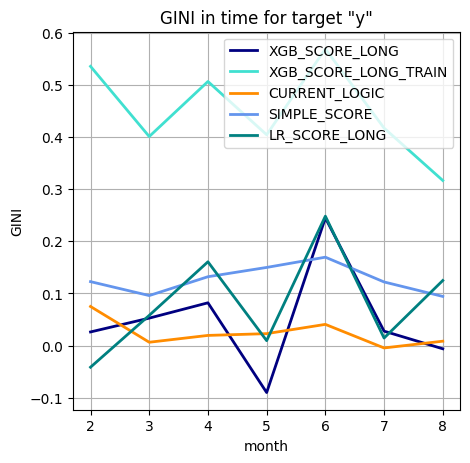

In [81]:
from mofr.basic_evaluators.GiniInTime import GiniInTimeEvaluator

gite=GiniInTimeEvaluator()
#help(gite)

gite.d(df_modelling.dropna(subset=['XGB_SCORE_LONG', 'XGB_SCORE_LONG_TRAIN'])).t([('y','one')]).s(['XGB_SCORE_LONG', 'XGB_SCORE_LONG_TRAIN', 'CURRENT_LOGIC', 'SIMPLE_SCORE', 'LR_SCORE_LONG']).tc('month')

gite.get_graph()

In [82]:
gite.get_table()
gite.table

,XGB_SCORE_LONG,XGB_SCORE_LONG_TRAIN,CURRENT_LOGIC,SIMPLE_SCORE,LR_SCORE_LONG
month,,,,,
2,0.026031,0.535669,0.074882,0.122570,-0.041618
3,0.052535,0.401006,0.006275,0.095854,0.057819
4,0.081960,0.506586,0.019379,0.131994,0.160632
5,-0.090234,0.404396,0.022782,0.149818,0.009331
6,0.244868,0.569143,0.040560,0.169485,0.248218
7,0.027543,0.417246,-0.004674,0.121951,0.014359
8,-0.006277,0.316675,0.008305,0.094179,0.124763
All,0.082608,0.452766,0.021901,0.127545,0.108689


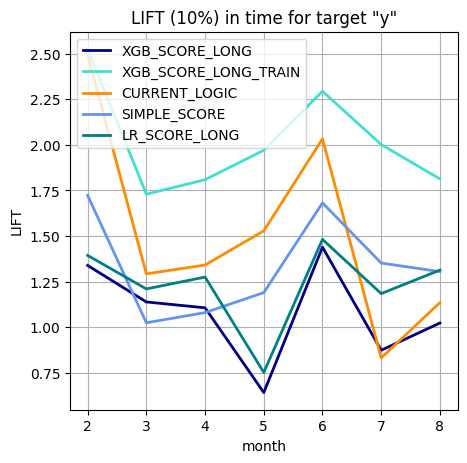

In [83]:
from mofr.basic_evaluators.LiftInTime import LiftInTimeEvaluator

lite=LiftInTimeEvaluator()
#help(lite)

lite.d(df_modelling.dropna(subset=['XGB_SCORE_LONG', 'XGB_SCORE_LONG_TRAIN'])).t([('y','one')]).s(['XGB_SCORE_LONG', 'XGB_SCORE_LONG_TRAIN', 'CURRENT_LOGIC', 'SIMPLE_SCORE', 'LR_SCORE_LONG']).tc('month')

lite.get_graph()

In [84]:
lite.get_table()
lite.table

,XGB_SCORE_LONG,XGB_SCORE_LONG_TRAIN,CURRENT_LOGIC,SIMPLE_SCORE,LR_SCORE_LONG
month,,,,,
2,1.339022,2.526193,2.494293,1.722934,1.393787
3,1.138824,1.729691,1.292901,1.024727,1.210190
4,1.106654,1.809113,1.341353,1.080400,1.275337
5,0.642120,1.970331,1.528682,1.190184,0.752459
6,1.439222,2.294068,2.033109,1.681935,1.481705
7,0.873878,2.002001,0.832002,1.352032,1.184489
8,1.023273,1.813108,1.135242,1.305195,1.313543
All,1.166551,1.975126,1.531850,1.298486,1.310549


## Short models

In [85]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['bid_price']

In [86]:
df_modelling=df_filtered.replace([np.inf, -np.inf], None).dropna(subset=feature_cols+['profit_long', 'profit_short']).reset_index(drop=True)

In [87]:
df_modelling['one']=1

In [88]:
#df_modelling=df_modelling[(df_modelling['MACD_12_26']<0.05)&(df_modelling['price_diff']<0.05)]
df_modelling=df_modelling[(df_modelling['ba_spread']<ba_max)]
#df_modelling=df_modelling[(df_modelling['month']<8)]

### XGBoost

In [89]:
df_modelling['y']=(df_modelling['profit_short']>0).apply(int)
df_modelling['y'].value_counts()

y
0    26407
1    16930
Name: count, dtype: int64

In [90]:
df_modelling['y'].value_counts(normalize=True)

y
0    0.609341
1    0.390659
Name: proportion, dtype: float64

In [91]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD_6_14,-0.087502
1,MACD_12_26,-0.075579
2,MACD_18_38,-0.066189
3,price_diff,-0.076236
4,predicted_return,-0.124591
5,ba_spread,-0.018393


In [92]:
# Create a new column to store the XGB_SCORE
df_modelling['XGB_SCORE_SHORT'] = None

# Sort the data by date
df_modelling = df_modelling.sort_values('date')

# Generate weekly ranges: We're going to use sliding windows with 2 weeks for training and 1 week for scoring
weeks = pd.date_range(df_modelling['date'].min(), df_modelling['date'].max(), freq='W')

for i in range(len(weeks) - 6):  # We subtract 5 to ensure we have enough weeks for a 4-week train and 1-week test
    train_start = weeks[i+2]
    train_end = weeks[i+2 + 3]  # End of the 4-week training period
    test_start = weeks[i]
    test_end = weeks[i + 2] # End of the 1-week test period\
    
    valid_start = weeks[i+2 + 3]
    valid_end = weeks[i+2 + 4] # End of the 1-week test period\
    
    #print(f'{test_start} and {test_end}')
    
    # Training data: last 2 weeks
    train_data = df_modelling[(df_modelling['date'] >= train_start) & (df_modelling['date'] < train_end)]
    
    # Testing data: next 1 week
    test_data = df_modelling[(df_modelling['date'] >= test_start) & (df_modelling['date'] < test_end)]
    
    # Testing data: next 1 week
    valid_data = df_modelling[(df_modelling['date'] >= valid_start) & (df_modelling['date'] < valid_end)]
    
    # Skip if there isn't enough data for the period
    if train_data.empty or test_data.empty:
        continue

 # Split into features and target
    X_train, y_train = train_data[feature_cols].apply(pd.to_numeric, errors='coerce'), train_data['y']
    X_test, y_test = test_data[feature_cols].apply(pd.to_numeric, errors='coerce'), test_data['y']
    X_valid, y_valid = valid_data[feature_cols].apply(pd.to_numeric, errors='coerce'), valid_data['y']


    # Create DMatrix for XGBoost (required for early stopping)
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)


    # Set up the parameters for XGBoost
    params = {
    'objective': 'binary:logistic',  # For binary classification
    'eval_metric': 'logloss',  # Use log-loss to evaluate performance
    'max_depth': 2,  # Prevent overfitting by limiting tree depth
    'eta': 0.1,  # Learning rate, lower to prevent overfitting
    'gamma': 1,  # Regularization to reduce overfitting
    'lambda': 1,  # L2 regularization term
    'alpha': 0.1  # L1 regularization term
    }

    # Set up evaluation list
    evals = [(dtrain, 'train'), (dtest, 'test')]

    # Train the model with early stopping
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=100,  # Maximum number of boosting rounds
        evals=evals,
        early_stopping_rounds=10,  # Stop if test error doesn't improve after 10 rounds
        verbose_eval=True  # Show progress
    )

    # Predict for the training and testing periods
    predictions_train = model.predict(dtrain)
    predictions = model.predict(dvalid)

    lr_model = LogisticRegression()
    lr_model.fit(X_train, y_train)
    
    predictions_lr=lr_model.predict_proba(X_valid)[:, 1]

    # Insert predictions into the original DataFrame
    df_modelling.loc[train_data.index, 'XGB_SCORE_SHORT_TRAIN'] = predictions_train
    df_modelling.loc[valid_data.index, 'XGB_SCORE_SHORT'] = predictions
    df_modelling.loc[valid_data.index, 'LR_SCORE_SHORT'] = predictions_lr

[0]	train-logloss:0.68708	test-logloss:0.68343
[1]	train-logloss:0.68287	test-logloss:0.68329
[2]	train-logloss:0.67909	test-logloss:0.68572
[3]	train-logloss:0.67559	test-logloss:0.68457
[4]	train-logloss:0.67114	test-logloss:0.68300
[5]	train-logloss:0.66801	test-logloss:0.68561
[6]	train-logloss:0.66437	test-logloss:0.68452
[7]	train-logloss:0.66163	test-logloss:0.68718
[8]	train-logloss:0.65920	test-logloss:0.68651
[9]	train-logloss:0.65683	test-logloss:0.68683
[10]	train-logloss:0.65452	test-logloss:0.68997
[11]	train-logloss:0.64988	test-logloss:0.69063
[12]	train-logloss:0.64793	test-logloss:0.69337
[13]	train-logloss:0.64581	test-logloss:0.69330
[14]	train-logloss:0.64294	test-logloss:0.69366
[0]	train-logloss:0.67873	test-logloss:0.69164
[1]	train-logloss:0.67379	test-logloss:0.69096
[2]	train-logloss:0.66962	test-logloss:0.69045
[3]	train-logloss:0.66532	test-logloss:0.68760
[4]	train-logloss:0.66180	test-logloss:0.68745
[5]	train-logloss:0.65869	test-logloss:0.68733
[6]	trai

[12]	train-logloss:0.63122	test-logloss:0.62508
[13]	train-logloss:0.62998	test-logloss:0.62469
[14]	train-logloss:0.62924	test-logloss:0.62485
[0]	train-logloss:0.65465	test-logloss:0.64256
[1]	train-logloss:0.65064	test-logloss:0.64128
[2]	train-logloss:0.64622	test-logloss:0.63938
[3]	train-logloss:0.64246	test-logloss:0.63753
[4]	train-logloss:0.63984	test-logloss:0.63821
[5]	train-logloss:0.63690	test-logloss:0.63741
[6]	train-logloss:0.63485	test-logloss:0.63767
[7]	train-logloss:0.63225	test-logloss:0.63734
[8]	train-logloss:0.63049	test-logloss:0.63817
[9]	train-logloss:0.62796	test-logloss:0.63742
[10]	train-logloss:0.62599	test-logloss:0.63744
[11]	train-logloss:0.62385	test-logloss:0.63810
[12]	train-logloss:0.62241	test-logloss:0.63949
[13]	train-logloss:0.62056	test-logloss:0.64003
[14]	train-logloss:0.61861	test-logloss:0.63965
[15]	train-logloss:0.61683	test-logloss:0.64062
[16]	train-logloss:0.61571	test-logloss:0.64210
[0]	train-logloss:0.66812	test-logloss:0.65319
[1]

[2]	train-logloss:0.66697	test-logloss:0.67829
[3]	train-logloss:0.66260	test-logloss:0.67990
[4]	train-logloss:0.65877	test-logloss:0.68080
[5]	train-logloss:0.65525	test-logloss:0.68110
[6]	train-logloss:0.65195	test-logloss:0.68183
[7]	train-logloss:0.64871	test-logloss:0.68438
[8]	train-logloss:0.64569	test-logloss:0.68584
[9]	train-logloss:0.64293	test-logloss:0.68654
[10]	train-logloss:0.64055	test-logloss:0.68711
[11]	train-logloss:0.63801	test-logloss:0.68977
[0]	train-logloss:0.67364	test-logloss:0.69680
[1]	train-logloss:0.66968	test-logloss:0.69345
[2]	train-logloss:0.66597	test-logloss:0.69356
[3]	train-logloss:0.66245	test-logloss:0.69028
[4]	train-logloss:0.65954	test-logloss:0.69126
[5]	train-logloss:0.65665	test-logloss:0.68952
[6]	train-logloss:0.65401	test-logloss:0.69129
[7]	train-logloss:0.65127	test-logloss:0.68925
[8]	train-logloss:0.64917	test-logloss:0.68780
[9]	train-logloss:0.64711	test-logloss:0.68837
[10]	train-logloss:0.64499	test-logloss:0.68965
[11]	train

[7]	train-logloss:0.57742	test-logloss:0.58994
[8]	train-logloss:0.57486	test-logloss:0.59103
[9]	train-logloss:0.57213	test-logloss:0.59102


In [93]:
print('The Lift on the train set is: '+ str(mofr.metrics.lift(df_modelling[df_modelling['XGB_SCORE_SHORT_TRAIN'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_SHORT_TRAIN'].isnull()==False]['XGB_SCORE_SHORT_TRAIN'])))
print('The gini on the train set is: '+ str(mofr.metrics.gini(df_modelling[df_modelling['XGB_SCORE_SHORT_TRAIN'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_SHORT_TRAIN'].isnull()==False]['XGB_SCORE_SHORT_TRAIN'])))
# print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['XGB_SCORE_SHORT'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['XGB_SCORE_SHORT'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['XGB_SCORE_SHORT'])))
# print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['y'], df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False]['XGB_SCORE_SHORT'].apply(lambda x: int(x>0.5)))))
print('\n')
# Sort the DataFrame by the XGB_SCORE_SHORT column in descending order
df_modelling['CURRENT_LOGIC']=((df_modelling['MACD_12_26']<-0.05)&(df_modelling['price_diff']<-0.1)&(df_modelling['XGB_SCORE_SHORT'].isnull()==False)).apply(int)
df_modelling['SIMPLE_SCORE']=-0.333*df_modelling['MACD_12_26']+df_modelling['price_diff']
n=sum(df_modelling['CURRENT_LOGIC'])
df_top100 = df_modelling.sort_values(by='XGB_SCORE_SHORT', ascending=False).head(n)
df_top100_train = df_modelling.sort_values(by='XGB_SCORE_SHORT_TRAIN', ascending=False).head(n)
df_top100_simple = df_modelling.sort_values(by='SIMPLE_SCORE', ascending=False).head(n)
df_top100_lr = df_modelling.sort_values(by='LR_SCORE_SHORT', ascending=False).head(n)



# Calculate precision based on the top 100 observations
precision_test = df_top100['y'].sum()/n
precision_train = df_top100_train['y'].sum()/n
precision_simple = df_top100_simple['y'].sum()/n
precision=df_modelling[df_modelling['CURRENT_LOGIC']==1]['y'].mean()
precision_lr = df_top100_lr['y'].sum()/n


# Create a DataFrame with the precision data
precision_data = {
    'Set': ['Train', 'Test', 'LR', 'Simple', 'Current Model'],
    'Top N Observations': [n, n, n, n, n],
    'Precision': [precision_train, precision_test, precision_lr, precision_simple,precision],
    'Unique Days': [
        len(df_top100_train['date'].unique()), 
        len(df_top100['date'].unique()), 
        len(df_top100_lr['date'].unique()), 
        len(df_top100_simple['date'].unique()), 
        len(df_modelling[df_modelling['CURRENT_LOGIC']==1]['date'].unique())
    ]
}

# Create DataFrame to store the results
df_precision = pd.DataFrame(precision_data)
df_precision

The Lift on the train set is: 1.9882415820416892
The gini on the train set is: 0.4265355379695972


The Lift on the test set is: 1.144026301782425
The gini on the test set is: 0.10226810128578312




,Set,Top N Observations,Precision,Unique Days
0,Train,664,0.896084,60
1,Test,664,0.414157,77
2,LR,664,0.444277,58
3,Simple,664,0.403614,96
4,Current Model,664,0.513554,94


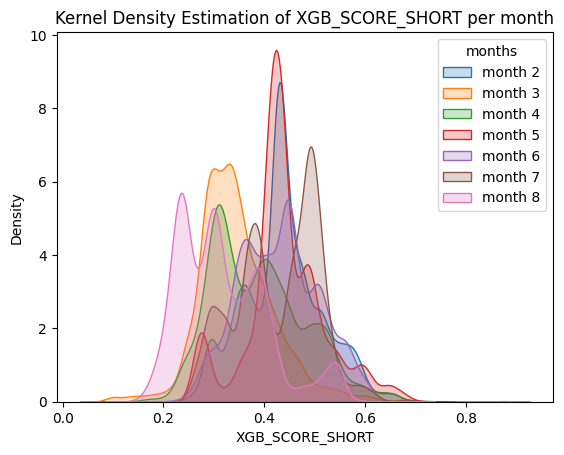

In [94]:
for month, group in df_modelling[df_modelling['XGB_SCORE_SHORT'].isnull()==False].groupby('month'):
    sns.kdeplot(group['XGB_SCORE_SHORT'], label=f'month {month}', fill=True, alpha=0.25)

# Add labels and legend
plt.xlabel('XGB_SCORE_SHORT')
plt.ylabel('Density')
plt.title('Kernel Density Estimation of XGB_SCORE_SHORT per month')
plt.legend(title='months')

# Show the plot
plt.show()

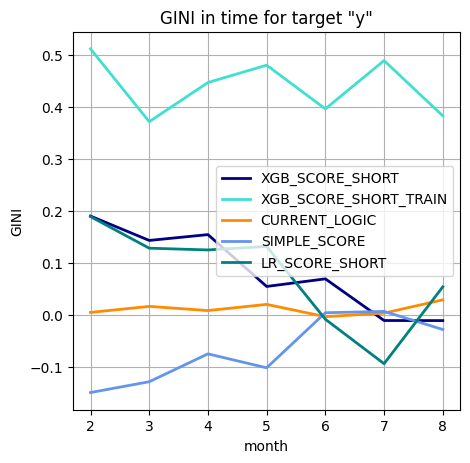

In [95]:
from mofr.basic_evaluators.GiniInTime import GiniInTimeEvaluator

gite=GiniInTimeEvaluator()
#help(gite)

gite.d(df_modelling.dropna(subset=['XGB_SCORE_SHORT', 'XGB_SCORE_SHORT_TRAIN'])).t([('y','one')]).s(['XGB_SCORE_SHORT', 'XGB_SCORE_SHORT_TRAIN', 'CURRENT_LOGIC', 'SIMPLE_SCORE', 'LR_SCORE_SHORT']).tc('month')

gite.get_graph()


In [96]:
gite.get_table()
gite.table

,XGB_SCORE_SHORT,XGB_SCORE_SHORT_TRAIN,CURRENT_LOGIC,SIMPLE_SCORE,LR_SCORE_SHORT
month,,,,,
2,0.189908,0.510801,0.005056,-0.148779,0.188866
3,0.143161,0.371141,0.016585,-0.128020,0.128294
4,0.154363,0.446271,0.008578,-0.074548,0.124940
5,0.054845,0.479577,0.020436,-0.101293,0.131625
6,0.069451,0.395645,-0.003155,0.004375,-0.008136
7,-0.010540,0.488383,0.003657,0.006971,-0.093436
8,-0.010685,0.382274,0.029189,-0.027750,0.054104
All,0.103043,0.421992,0.010920,-0.067385,0.084970


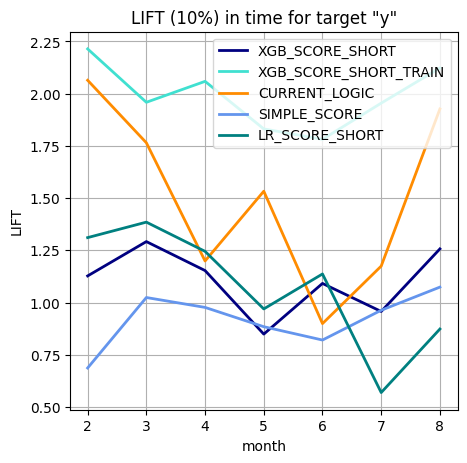

In [97]:
from mofr.basic_evaluators.LiftInTime import LiftInTimeEvaluator

lite=LiftInTimeEvaluator()
#help(lite)

lite.d(df_modelling.dropna(subset=['XGB_SCORE_SHORT', 'XGB_SCORE_SHORT_TRAIN'])).t([('y','one')]).s(['XGB_SCORE_SHORT', 'XGB_SCORE_SHORT_TRAIN', 'CURRENT_LOGIC', 'SIMPLE_SCORE', 'LR_SCORE_SHORT']).tc('month')

lite.get_graph()

In [98]:
lite.get_table()
lite.table

,XGB_SCORE_SHORT,XGB_SCORE_SHORT_TRAIN,CURRENT_LOGIC,SIMPLE_SCORE,LR_SCORE_SHORT
month,,,,,
2,1.127465,2.214407,2.064256,0.686785,1.310887
3,1.291846,1.958834,1.764972,1.024102,1.385034
4,1.153163,2.059051,1.199041,0.976788,1.245074
5,0.848924,1.831452,1.532951,0.884321,0.969493
6,1.091566,1.781419,0.899325,0.820556,1.136828
7,0.957351,1.954750,1.174539,0.963193,0.569160
8,1.256910,2.123095,1.926926,1.073965,0.873281
All,1.134575,2.003559,1.416597,0.919888,1.118342
